<a href="https://colab.research.google.com/github/rmmartinez015-maker/TestDatasets/blob/main/ReynaMartinez_PythonAnalysis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summary of Data Analysis

Data file consists of a total of (69637) rows with a total of (21) columns. Data types are mostly object with a (1) interger and (3) float types. This covers a range of incidents reported in the second week of May 2019 to various agencies in New York State.

For data clean up, all column names were cleaned up and then data was reviewed for bad values. incident_zip and bbl data type was changed from object to float64 in this process. Additionally, columns holding dates were formated correctly, changing their data type from object to datetime64[ns].

For data replacement, mode was used for a majority of data based on data type and only 'City' was based on the mode for 'Incident_zip' so that it aligned with the actual zipcode provided. Blank cells from (4) columns were replaced with N/A for standardization of data.

A total of (8) columns were changed from object to categorical columns. Which were reviewed and compared visually using univariate and bivariate analysis.Showing that the majority of incidents were received by the NYPD, covering mostly the Queens and Brooklyn areas, located on the street or within a residential building. Primary cause of incident is a Noise Complaint in a residential area.

There is no distinct correlation between the data provided but based on the incident dates, there is a pattern of reports based on the time of day. To further investigate coorelation, there may be need to calculate the duration of start to close of an incident, which should help understand how quickly the agency responds to any type of situation.


In [8]:
#importing libraries for analysis
import pandas as pd
import numpy as np
!pip install matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#loading data file into a dataframe
df=pd.read_csv("https://raw.githubusercontent.com/rmmartinez015-maker/TestDatasets/refs/heads/main/311_Service_Requests_from_2019May.csv")
#showing top 5 rows
df.head()

/tmp/ipykernel_80382/626076081.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("https://raw.githubusercontent.com/rmmartinez015-maker/TestDatasets/refs/heads/main/311_Service_Requests_from_2019May.csv")


,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,...,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
0,42680103,5/1/2019 0:00,5/16/2019 21:45,DEP,Water System,NaN,11420.0,127-16 111 AVENUE,111 AVENUE,ADDRESS,...,NaN,NaN,Closed,NaN,The Department of Environment Protection inspe...,4.116320e+09,QUEENS,40.682565,-73.814060,"(40.682565064146196, -73.81406015056832)"
1,42530481,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10011.0,207 WEST 14 STREET,WEST 14 STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 22:17,Callers should contact the DOHMH Foodborne Ill...,1.007640e+09,MANHATTAN,40.738791,-74.000224,"(40.738790792032844, -74.00022373020307)"
2,42527619,5/1/2019 0:00,5/13/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10025.0,2664 BROADWAY,BROADWAY,ADDRESS,...,NaN,NaN,Closed,5/15/2019 10:04,The Department of Health and Mental Hygiene wi...,1.018730e+09,MANHATTAN,40.798040,-73.969300,"(40.79804015465285, -73.96930001020544)"
3,42526597,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11208.0,624 SOUTH CONDUIT BOULEVARD,SOUTH CONDUIT BOULEVARD,ADDRESS,...,NaN,NaN,Closed,5/15/2019 17:27,The Department of Health and Mental Hygiene wi...,3.042380e+09,BROOKLYN,40.675905,-73.866660,"(40.67590510222738, -73.86665990579837)"
4,42526595,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11106.0,31-91 21 STREET,21 STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 17:12,The Department of Health and Mental Hygiene wi...,4.005540e+09,QUEENS,40.765367,-73.931540,"(40.76536704921336, -73.93154011254339)"


In [10]:
#look up numbers of rows and columns
print ("shape (rows, columns):", df.shape)

#list column names
print ("\ncolumn names:")
print (df.columns)

#data types and non-null counts
print ("\nData types and non-null counts:")
df.info ()

#summary stats for All columns only
print ("\nSummary statistics (all columns):")
df.describe(include= "all")

shape (rows, columns): (69637, 21)

column names:
Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Complaint Type',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Address Type', 'City', 'Landmark', 'Facility Type', 'Status',
       'Due Date', 'Resolution Description', 'BBL', 'Borough', 'Latitude',
       'Longitude', 'Location'],
      dtype='object')

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69637 entries, 0 to 69636
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unique Key              69637 non-null  int64  
 1   Created Date            69637 non-null  object 
 2   Closed Date             64626 non-null  object 
 3   Agency                  69637 non-null  object 
 4   Complaint Type          69637 non-null  object 
 5   Location Type           53978 non-null  object 
 6   Incident Zip            

,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,...,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
count,6.963700e+04,69637,64626,69637,69637,53978,67389.0,59033,59032,68307,...,16,24081,69637,32839,63579,5.570200e+04,69637,65634.000000,65634.000000,65634
unique,NaN,11844,15797,20,186,98,407.0,37426,5564,5,...,11,3,6,17657,445,NaN,6,NaN,NaN,42165
top,NaN,5/7/2019 14:59,5/10/2019 0:00,NYPD,Noise - Residential,Street/Sidewalk,11385.0,78-15 PARSONS BOULEVARD,BROADWAY,ADDRESS,...,CENTRAL PARK,Precinct,Closed,6/14/2019 18:04,The Police Department responded to the complai...,NaN,BROOKLYN,NaN,NaN,"(40.72195913199264, -73.80969682426189)"
freq,NaN,42,840,21188,5838,13748,690.0,408,538,57140,...,4,21147,62548,374,7764,NaN,22247,NaN,NaN,408
mean,4.260307e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.869652e+09,NaN,40.723149,-73.924517,NaN
std,5.269818e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.184250e+09,NaN,0.083621,0.085089,NaN
min,4.251278e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,40.500025,-74.252279,NaN
25%,4.258004e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.030690e+09,NaN,40.664461,-73.972161,NaN
50%,4.260019e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.034830e+09,NaN,40.716443,-73.929758,NaN
75%,4.262095e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.023330e+09,NaN,40.780783,-73.874064,NaN


In [26]:
#look for random 10 rows, set state
df.sample(10, random_state=30)

,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,...,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
67086,42802310,5/9/2019 16:45,5/28/2019 8:40,HPD,WATER LEAK,RESIDENTIAL BUILDING,10462.0,2036 CRUGER AVENUE,CRUGER AVENUE,ADDRESS,...,NaN,NaN,Closed,NaN,The Department of Housing Preservation and Dev...,2.042850e+09,BRONX,40.851440,-73.866778,"(40.851439872463665, -73.86677792790597)"
38452,42599409,5/6/2019 10:39,5/10/2019 0:00,DSNY,Request Large Bulky Item Collection,Sidewalk,10306,3465 AMBOY ROAD,AMBOY ROAD,ADDRESS,...,NaN,NaN,Closed,NaN,NaN,5.045008e+09,STATEN ISLAND,40.557052,-74.138757,"(40.55705178473356, -74.13875651053864)"
34792,42598366,5/5/2019 18:27,5/11/2019 12:00,DSNY,Missed Collection (All Materials),NaN,11233,541 BAINBRIDGE STREET,BAINBRIDGE STREET,ADDRESS,...,NaN,DSNY Garage,Closed,NaN,The Department of Sanitation collected the req...,3.015060e+09,BROOKLYN,40.682778,-73.915371,"(40.68277749794197, -73.91537120764335)"
49829,42607952,5/7/2019 15:11,5/8/2019 3:29,NYPD,Illegal Parking,Street/Sidewalk,10028,130 EAST END AVENUE,EAST END AVENUE,ADDRESS,...,NaN,Precinct,Closed,5/7/2019 23:11,The Police Department responded and upon arriv...,1.015820e+09,MANHATTAN,40.774698,-73.944951,"(40.77469811978997, -73.94495074208145)"
38770,42602241,5/6/2019 11:08,5/9/2019 16:00,DPR,Damaged Tree,Street,10314,156 GRAVES STREET,GRAVES STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 8:33,The Department of Parks and Recreation visited...,5.008130e+09,STATEN ISLAND,40.601899,-74.129429,"(40.60189907520298, -74.12942908632151)"
44273,42598890,5/6/2019 22:28,5/6/2019 22:56,NYPD,Noise - Vehicle,Street/Sidewalk,11212,EAST 95 STREET,EAST 95 STREET,BLOCKFACE,...,NaN,Precinct,Closed,5/7/2019 6:28,The Police Department reviewed your complaint ...,NaN,BROOKLYN,40.664184,-73.926410,"(40.66418373811897, -73.92641020203364)"
48068,42607439,5/7/2019 12:04,5/7/2019 15:23,DOF,DOF Property - Update Account,Property Address,10469,NaN,NaN,ADDRESS,...,NaN,NaN,Closed,5/17/2019 12:04,See notes.,2.047490e+09,BRONX,NaN,NaN,NaN
4919,42525395,5/1/2019 15:02,5/2/2019 14:01,DPR,Damaged Tree,Street,11379.0,63-57 77 STREET,77 STREET,ADDRESS,...,NaN,NaN,Closed,5/10/2019 6:52,The Department of Parks and Recreation visited...,4.029870e+09,QUEENS,40.718594,-73.878483,"(40.718593878443954, -73.87848273336517)"
35309,42594755,5/5/2019 20:36,5/5/2019 21:30,DOT,Traffic Signal Condition,NaN,11102,NaN,NaN,INTERSECTION,...,NaN,NaN,Closed,NaN,Service Request status for this request is ava...,NaN,QUEENS,40.768618,-73.925075,"(40.768618289751124, -73.92507456786171)"
11548,42562980,5/2/2019 12:17,5/3/2019 6:10,NYPD,Derelict Vehicle,Street/Sidewalk,10466.0,3535 DEREIMER AVENUE,DEREIMER AVENUE,ADDRESS,...,NaN,Precinct,Closed,5/2/2019 20:17,This complaint does not fall under the Police ...,2.049180e+09,BRONX,40.882103,-73.838115,"(40.882102687952376, -73.83811488917284)"


In [11]:
#count of missing values per column
print ("Missing values per column:")
print (df.isna().sum())

#percentage of missing values per column
print ("\nPercentage of missing values per column:")
print ((df.isna().mean() *100).round(2))

#number of unique values per column
print ("\nNumber of uniquie values per column:")
print (df.nunique())

Missing values per column:
Unique Key                    0
Created Date                  0
Closed Date                5011
Agency                        0
Complaint Type                0
Location Type             15659
Incident Zip               2248
Incident Address          10604
Street Name               10605
Address Type               1330
City                       2221
Landmark                  69621
Facility Type             45556
Status                        0
Due Date                  36798
Resolution Description     6058
BBL                       13935
Borough                       0
Latitude                   4003
Longitude                  4003
Location                   4003
dtype: int64

Percentage of missing values per column:
Unique Key                 0.00
Created Date               0.00
Closed Date                7.20
Agency                     0.00
Complaint Type             0.00
Location Type             22.49
Incident Zip               3.23
Incident Address      

# Data clean up and modification

In [10]:
#clean column names: strip spaces, make lowercase, replace spaces with underscores
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print ("Cleaned column names:")
print (df.columns)

Cleaned column names:
Index(['unique_key', 'created_date', 'closed_date', 'agency', 'complaint_type',
       'location_type', 'incident_zip', 'incident_address', 'street_name',
       'address_type', 'city', 'landmark', 'facility_type', 'status',
       'due_date', 'resolution_description', 'bbl', 'borough', 'latitude',
       'longitude', 'location'],
      dtype='object')


In [11]:
#replace the string "nan" with actual missing value (np.nan)
df["incident_zip"] = df["incident_zip"].replace("nan", np.nan)
df["bbl"] = df["bbl"].replace("nan", np.nan)

#convert column to numeric, coercing bad values to NaN
df["incident_zip"] = pd.to_numeric(df["incident_zip"], errors="coerce")
df["bbl"] = pd.to_numeric(df["bbl"], errors="coerce")

#convert column to date/time format
df['created_date'] = pd.to_datetime(df['created_date'], errors="coerce")
df['closed_date'] = pd.to_datetime(df['closed_date'], errors="coerce")
df['due_date'] = pd.to_datetime(df['due_date'], errors="coerce")

#check types again
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69637 entries, 0 to 69636
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   unique_key              69637 non-null  int64         
 1   created_date            69637 non-null  datetime64[ns]
 2   closed_date             64626 non-null  datetime64[ns]
 3   agency                  69637 non-null  object        
 4   complaint_type          69637 non-null  object        
 5   location_type           53978 non-null  object        
 6   incident_zip            67388 non-null  float64       
 7   incident_address        59033 non-null  object        
 8   street_name             59032 non-null  object        
 9   address_type            68307 non-null  object        
 10  city                    67416 non-null  object        
 11  landmark                16 non-null     object        
 12  facility_type           24081 non-null  object

In [12]:
#compute for mode
df["closed_date"].mode()
print(df["closed_date"].mode())

df["location_type"].mode()
print(df["location_type"].mode())

df["incident_zip"].mode()
print(df["incident_zip"].mode())

df["address_type"].mode()
print(df["address_type"].mode())

df["due_date"].mode()
print(df["due_date"].mode())

df["resolution_description"].mode()
print(df["resolution_description"].mode())

df["bbl"].mode()
print(df["bbl"].mode())

df["latitude"].mode()
print(df["latitude"].mode())

df["longitude"].mode()
print(df["longitude"].mode())

df["location"].mode()
print(df["location"].mode())

#fill missing values with mode
df["closed_date"] = df["closed_date"].fillna(df["closed_date"].mode()[0])
df["location_type"] = df["location_type"].fillna(df["location_type"].mode()[0])
df["incident_zip"] = df["incident_zip"].fillna(df["incident_zip"].mode()[0])
df["address_type"] = df["address_type"].fillna(df["address_type"].mode()[0])
df["due_date"] = df["due_date"].fillna(df["due_date"].mode()[0])
df["resolution_description"] = df["resolution_description"].fillna(df["resolution_description"].mode()[0])
df["bbl"] = df["bbl"].fillna(df["bbl"].mode()[0])
df["latitude"] = df["latitude"].fillna(df["latitude"].mode()[0])
df["longitude"] = df["longitude"].fillna(df["longitude"].mode()[0])
df["location"] = df["location"].fillna(df["location"].mode()[0])

#fill missing values with city based on "incident_zip" instead of using mode
df["city"] = df["city"].fillna('RIDGEWOOD')

#fill missing values with "N/A"
df["incident_address"] = df["incident_address"].fillna('N/A')
df["street_name"] = df["street_name"].fillna('N/A')
df["landmark"] = df["landmark"].fillna('N/A')
df["facility_type"] = df["facility_type"].fillna('N/A')


# Replace 'old_text' with 'new_text' in 'column_name'
df['borough'] = df['borough'].str.replace('Unspecified', 'QUEENS', regex=False)
df['location_type'] = df['location_type'].str.replace('Street/Sidewalk', 'Street', regex=False)
df['location_type'] = df['location_type'].str.replace('Residential Building/House', 'RESIDENTIAL BUILDING', regex=False)
df['location_type'] = df['location_type'].str.replace('Sidewalk', 'Street', regex=False)
df['location_type'] = df['location_type'].str.replace('RESIDENTIAL BUILDING', 'Residential Building', regex=False)

0   2019-05-10
Name: closed_date, dtype: datetime64[ns]
0    Street/Sidewalk
Name: location_type, dtype: object
0    11385.0
Name: incident_zip, dtype: float64
0    ADDRESS
Name: address_type, dtype: object
0   2019-06-14 18:04:00
Name: due_date, dtype: datetime64[ns]
0    The Police Department responded to the complai...
Name: resolution_description, dtype: object
0    4.068290e+09
Name: bbl, dtype: float64
0    40.721959
Name: latitude, dtype: float64
0   -73.809697
Name: longitude, dtype: float64
0    (40.72195913199264, -73.80969682426189)
Name: location, dtype: object


In [16]:
#check for missing values after conversions & replacement
df.isna().sum()


,0
unique_key,0
created_date,0
closed_date,0
agency,0
complaint_type,0
location_type,0
incident_zip,0
incident_address,0
street_name,0
address_type,0


In [37]:
categorical_cols = [
    "agency",
    "complaint_type",
    "location_type",
    "landmark",
    "facility_type",
    "status",
    "borough"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

#check column types
df[categorical_cols].dtypes

,0
agency,category
complaint_type,category
location_type,category
landmark,category
facility_type,category
status,category
borough,category


# Review data and relationships

In [18]:
#gets count for categories

#df["agency"].value_counts()
df["complaint_type"].value_counts()
#df["city"].value_counts()
#df["borough"].value_counts()

,count
complaint_type,
Noise - Residential,5838
Request Large Bulky Item Collection,5301
Illegal Parking,5257
Blocked Driveway,3391
Street Condition,3080
...,...
Tanning,1
Taxi Compliment,1
Tattooing,1


In [19]:
#data types and non-null counts
print ("\nData types and non-null counts:")
df.info ()

#summary stats for All columns only
print ("\nSummary statistics (all columns):")
df.describe(include= "all")

# Select numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Summary statistics for all numeric columns
numeric_df.describe()


Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69637 entries, 0 to 69636
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   unique_key              69637 non-null  int64         
 1   created_date            69637 non-null  datetime64[ns]
 2   closed_date             69637 non-null  datetime64[ns]
 3   agency                  69637 non-null  category      
 4   complaint_type          69637 non-null  category      
 5   location_type           69637 non-null  category      
 6   incident_zip            69637 non-null  category      
 7   incident_address        69637 non-null  object        
 8   street_name             69637 non-null  object        
 9   address_type            69637 non-null  object        
 10  city                    69637 non-null  category      
 11  landmark                69637 non-null  category      
 12  facility_type

,unique_key,bbl,latitude,longitude
count,6.963700e+04,6.963700e+04,69637.000000,69637.000000
mean,4.260307e+07,3.109510e+09,40.723081,-73.917917
std,5.269818e+04,1.162659e+09,0.081183,0.086823
min,4.251278e+07,0.000000e+00,40.500025,-74.252279
25%,4.258004e+07,2.042470e+09,40.668366,-73.968007
50%,4.260019e+07,3.066560e+09,40.721959,-73.923589
75%,4.262095e+07,4.068290e+09,40.773890,-73.858763
max,4.297343e+07,5.080480e+09,40.912869,-73.700597


In [21]:
print("Agency summary:")
print(df["agency"].describe())

print("Complaint Type summary:")
print(df["complaint_type"].describe())

print("Borough summary:")
print(df["borough"].describe())

Agency summary:
count     69637
unique       20
top        NYPD
freq      21188
Name: agency, dtype: object
Complaint Type summary:
count                   69637
unique                    186
top       Noise - Residential
freq                     5838
Name: complaint_type, dtype: object
Borough summary:
count        69637
unique           5
top       BROOKLYN
freq         22247
Name: borough, dtype: object


In [22]:
def show_category_distribution(complaint_type):
    """
    Print and display the count and percentage of each category for a given column.
    """
    print(f"--- {complaint_type} ---")
    counts = df[complaint_type].value_counts()
    percents = df[complaint_type].value_counts(normalize=True) * 100
    display(pd.DataFrame({"count": counts, "percent": percents.round(2)}))
    print("\n")

for col in ["agency", "borough", "created_date", "closed_date", "location_type", "bbl"]:
    show_category_distribution(col)

--- agency ---


,count,percent
agency,,
NYPD,21188,30.43
DSNY,11262,16.17
HPD,11215,16.10
DOT,8208,11.79
DEP,5179,7.44
DOB,4150,5.96
DPR,3065,4.40
DOHMH,1868,2.68
DOF,1259,1.81




--- borough ---


,count,percent
borough,,
BROOKLYN,22247,31.95
QUEENS,19484,27.98
MANHATTAN,13133,18.86
BRONX,10925,15.69
STATEN ISLAND,3848,5.53




--- created_date ---


...

,count,percent
closed_date,,
2019-05-10 00:00:00,5851,8.40
2019-05-08 00:00:00,822,1.18
2019-05-09 00:00:00,819,1.18
2019-05-07 00:00:00,777,1.12
2019-05-11 00:00:00,687,0.99
...,...,...
2019-06-01 11:41:00,1,0.00
2019-05-13 10:34:00,1,0.00
2019-06-05 16:22:00,1,0.00




--- location_type ---


,count,percent
location_type,,
Street,45612,65.50
Residential Building,17328,24.88
Store/Commercial,947,1.36
Park,573,0.82
Club/Bar/Restaurant,528,0.76
...,...,...
Steam Room,1,0.00
Single Room Occupancy (SRO),1,0.00
Tattoo Parlor,1,0.00




--- bbl ---


,count,percent
bbl,,
4.068290e+09,14343,20.60
4.034500e+09,148,0.21
4.068540e+09,109,0.16
3.087560e+09,101,0.15
3.009340e+09,100,0.14
...,...,...
4.000420e+09,1,0.00
3.010270e+09,1,0.00
3.058920e+09,1,0.00


# Data visualization

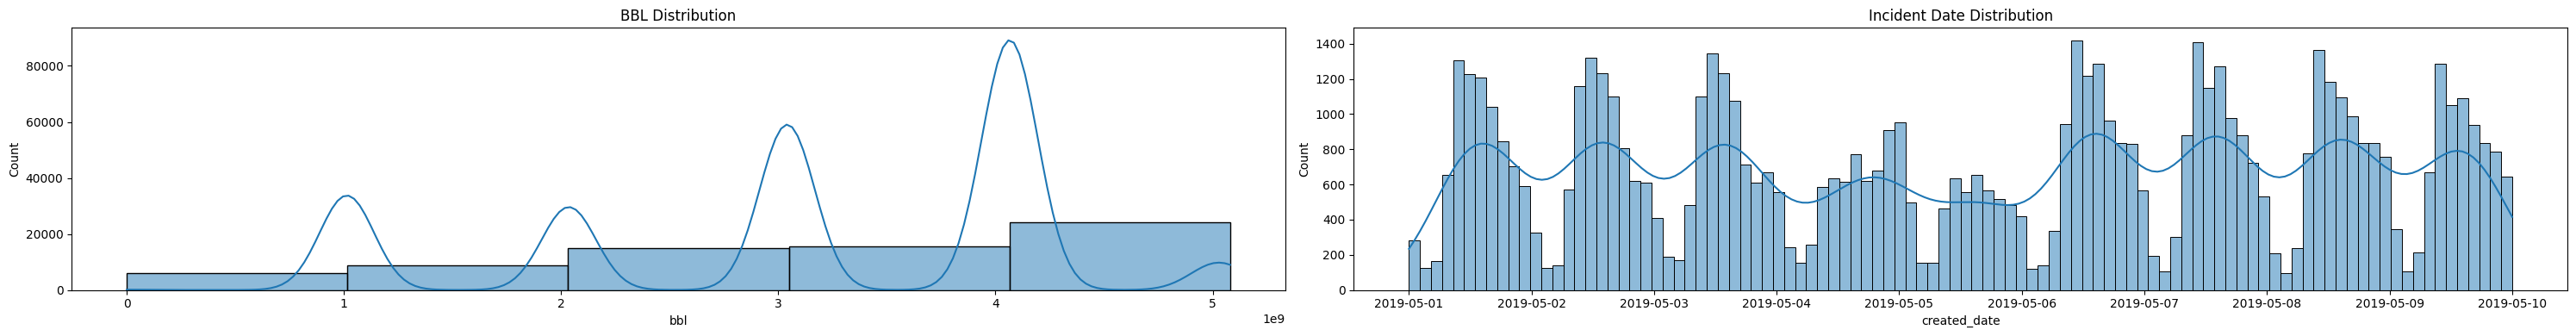

In [45]:
# Histograms
fig, axes = plt.subplots(1, 2, figsize=(30, 4))

sns.histplot(df["bbl"], bins=5, kde=True, ax=axes[0])
axes[0].set_title("BBL Distribution")

sns.histplot(df["created_date"], bins=100, kde=True, ax=axes[1])
axes[1].set_title("Incident Date Distribution")

plt.tight_layout()
plt.show()

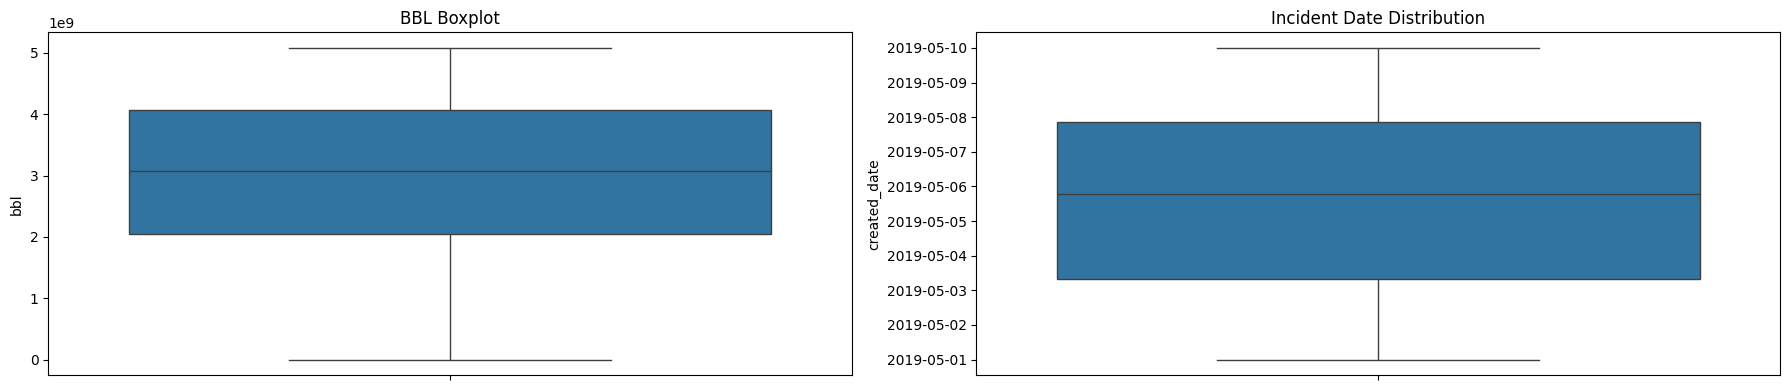

In [43]:
# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

sns.boxplot(y=df["bbl"], ax=axes[0])
axes[0].set_title("BBL Boxplot")

sns.boxplot(y=df["created_date"], ax=axes[1])
axes[1].set_title("Incident Date Distribution")

plt.tight_layout()
plt.show()

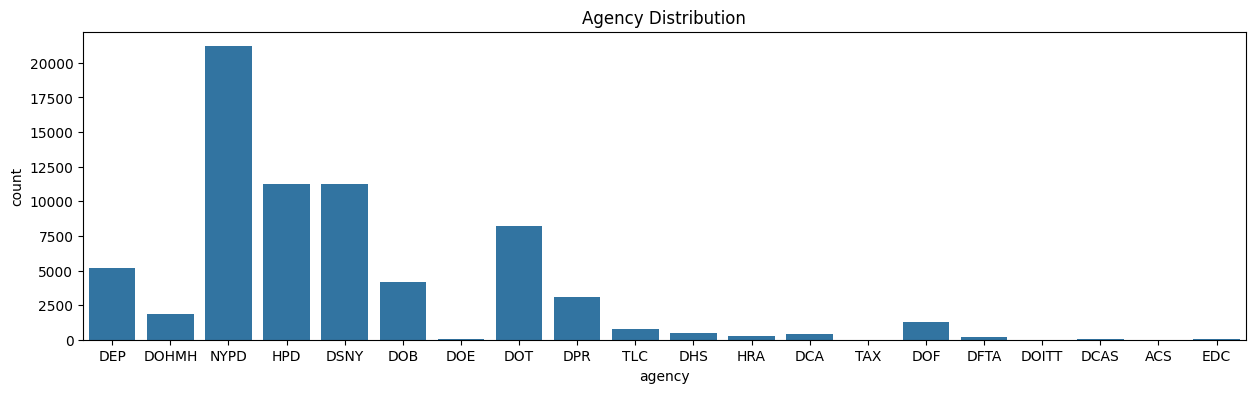

In [20]:
plt.figure(figsize=(15, 4))
sns.countplot(x="agency", data=df)
plt.title("Agency Distribution")
plt.show()

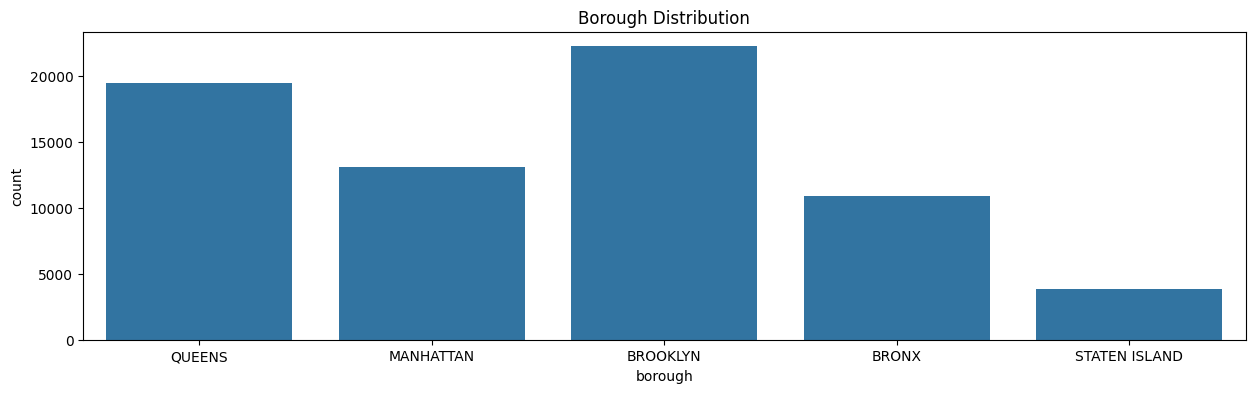

In [27]:
plt.figure(figsize=(15, 4))
sns.countplot(x="borough", data=df)
plt.title("Borough Distribution")
plt.show()

In [71]:
# Compare complaint to incident date, close date, and bbl
grouped_incident = df.groupby("complaint_type")[["bbl", "created_date", "closed_date"]].mean().round(2)
grouped_incident

/tmp/ipykernel_80382/1218478126.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_incident = df.groupby("complaint_type")[["bbl", "created_date", "closed_date"]].mean().round(2)


,bbl,created_date,closed_date
complaint_type,,,
APPLIANCE,2.352300e+09,2019-05-05 10:53:32.204472832,2019-05-17 09:05:08.242811392
Advocate - Other,3.777791e+09,2019-05-05 01:33:15.000000000,2019-05-05 01:42:15.000000000
Advocate-Co-opCondo Abatement,2.055060e+09,2019-05-09 11:04:00.000000000,2019-05-09 11:13:00.000000000
Advocate-Personal Exemptions,3.652072e+09,2019-05-04 06:27:00.000000000,2019-05-04 06:36:12.000000000
Advocate-Prop Refunds/Credits,2.029253e+09,2019-05-07 04:59:10.000000000,2019-05-07 05:09:30.000000000
...,...,...,...
WATER LEAK,2.481256e+09,2019-05-05 17:32:47.520661248,2019-05-17 14:33:26.859504128
Water Conservation,3.512676e+09,2019-05-06 01:34:21.081081088,2019-05-06 07:11:43.783783680
Water Quality,3.019222e+09,2019-05-05 18:31:09.000000000,2019-05-12 18:50:15.000000000


/tmp/ipykernel_80382/273709316.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x="created_date", hue="status", shade=True)


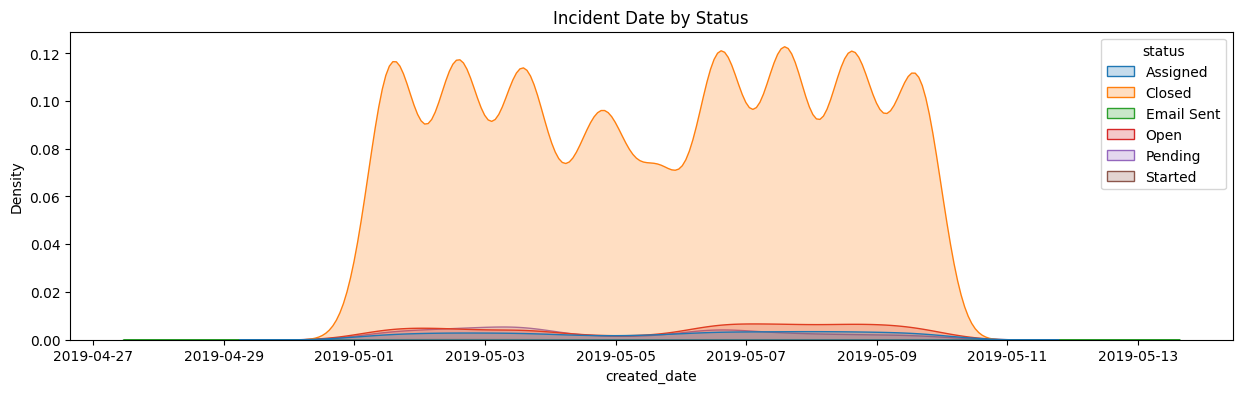

In [75]:
#incident date by status
plt.figure(figsize=(15, 4))
sns.kdeplot(data=df, x="created_date", hue="status", shade=True)
plt.title("Incident Date by Status")
plt.show()

In [78]:
# Correlation matrix for numeric columns
corr_matrix = df.select_dtypes(include=["int64", "float64", "datetime64[ns]"]).corr()

corr_matrix


,unique_key,created_date,closed_date,incident_zip,due_date,bbl,latitude,longitude
unique_key,1.000000,0.542288,0.633184,-0.068409,0.031037,-0.147263,0.126434,-0.002027
created_date,0.542288,1.000000,0.350175,-0.002717,0.022826,0.004965,0.000048,0.004545
closed_date,0.633184,0.350175,1.000000,-0.029169,0.084557,-0.072255,0.037612,0.014064
incident_zip,-0.068409,-0.002717,-0.029169,1.000000,-0.000189,0.474970,-0.360998,0.349573
due_date,0.031037,0.022826,0.084557,-0.000189,1.000000,0.014152,-0.030527,-0.035214
bbl,-0.147263,0.004965,-0.072255,0.474970,0.014152,1.000000,-0.497141,0.127974
latitude,0.126434,0.000048,0.037612,-0.360998,-0.030527,-0.497141,1.000000,0.352243
longitude,-0.002027,0.004545,0.014064,0.349573,-0.035214,0.127974,0.352243,1.000000


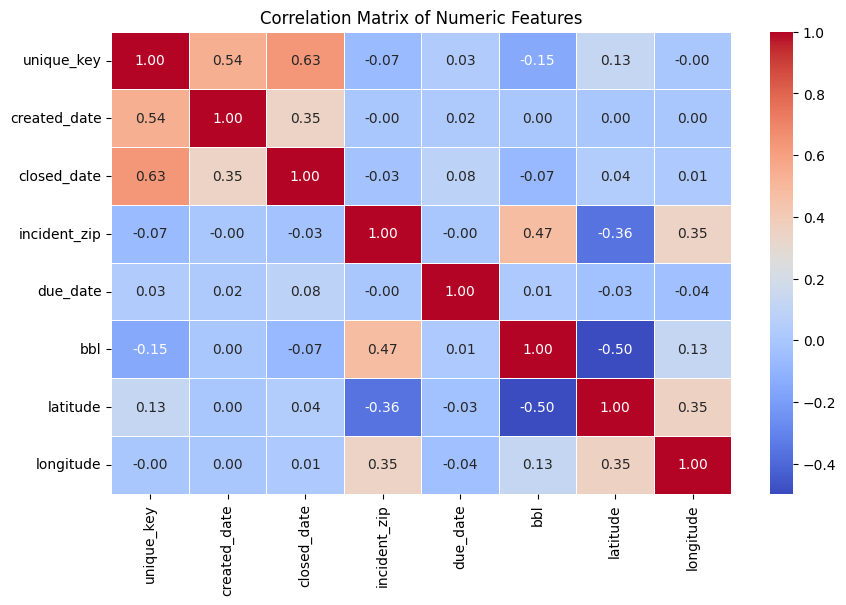

In [79]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [80]:
output_file = "311_Service_Requests_from_2019May.csv"
df.to_csv(output_file, index=False)

print(f"Cleaned data saved to: {output_file}")

Cleaned data saved to: 311_Service_Requests_from_2019May.csv
